### Step 1: Load the Libraies and Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import ElasticNetCV
from numpy.linalg import lstsq
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.layers import LSTM, Dense, Dropout, GRU, Conv1D, SimpleRNN
from keras.callbacks import EarlyStopping 

In [2]:
# extracting the data 
data = pd.read_csv(".\datasets\T1.csv")
data.head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\aalma\AppData\Local\Temp\ipykernel_25952\1502131984.py:2: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv(".\datasets\T1.csv")


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


## Section 1: Data Description

In [3]:
# data decsription (we can see that the data is not normalized) 
data.describe()

,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
count,50530.000000,50530.000000,50530.000000,50530.000000
mean,1307.684332,7.557952,1492.175463,123.687559
std,1312.459242,4.227166,1368.018238,93.443736
min,-2.471405,0.000000,0.000000,0.000000
25%,50.677890,4.201395,161.328167,49.315437
50%,825.838074,7.104594,1063.776283,73.712978
75%,2482.507568,10.300020,2964.972462,201.696720
max,3618.732910,25.206011,3600.000000,359.997589


In [4]:
# data information (Data types, missing values, etc.)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  object 
 1   LV ActivePower (kW)            50530 non-null  float64
 2   Wind Speed (m/s)               50530 non-null  float64
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64
 4   Wind Direction (°)             50530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.9+ MB


In [5]:
data.isnull().sum()

Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64

In [6]:
# Spliting the date time in year, month, days, hours and minutes
data['Year']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[0])
data['Month']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[1])
data['Day']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[2])
data['Time_Hours']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[3])
data['Time_Minutes']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[4])
data.head(5)

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904,2018,1,1,0,0
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113,2018,1,1,0,10
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789,2018,1,1,0,20
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087,2018,1,1,0,30
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286,2018,1,1,0,40


In [7]:
# convert a datetime to a timestamp
data['Date/Time'] = pd.to_datetime(data['Date/Time'], format='%d %m %Y %H:%M')
data


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,2018,1,1,0,0
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,2018,1,1,0,10
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,2018,1,1,0,20
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,2018,1,1,0,30
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,2018,1,1,0,40
...,...,...,...,...,...,...,...,...,...,...
50525,2018-12-31 23:10:00,2963.980957,11.404030,3397.190793,80.502724,2018,12,31,23,10
50526,2018-12-31 23:20:00,1684.353027,7.332648,1173.055771,84.062599,2018,12,31,23,20
50527,2018-12-31 23:30:00,2201.106934,8.435358,1788.284755,84.742500,2018,12,31,23,30
50528,2018-12-31 23:40:00,2515.694092,9.421366,2418.382503,84.297913,2018,12,31,23,40


In [8]:
# Filter data for the selected month and reset index
x = [1]  # Convert x to a list
data1 = data.loc[data['Month'].isin(x)]  # Selecting the data for the month x
data1 = data1.reset_index(drop=True)  # Resetting the index
data1 = data1.dropna()  # Dropping the missing values

data_wind = data1[['LV ActivePower (kW)', 'Wind Direction (°)', 'Theoretical_Power_Curve (KWh)', 'Wind Speed (m/s)']]

# Separate input feature and target
features = data_wind[['LV ActivePower (kW)', 'Wind Direction (°)', 'Theoretical_Power_Curve (KWh)', 'Wind Speed (m/s)']]
target = data_wind['LV ActivePower (kW)']


In [9]:
features['Wind Speed (m/s)'] = np.log1p(features['Wind Speed (m/s)'])

In [10]:
scaler_features = MinMaxScaler()

# Fit the scaler on the features data
scaler_features.fit(features[['Theoretical_Power_Curve (KWh)', 'Wind Direction (°)', 'LV ActivePower (kW)', 'Wind Speed (m/s)']])

# Manually adjust the scaler for Wind Direction
# Suppose the predefined range for Wind Direction is 0 to 360 degrees
wind_dir_index = features.columns.get_loc('Wind Direction (°)')  # Get the column index for Wind Direction
scaler_features.data_min_[wind_dir_index] = 0   # Set minimum to 0
scaler_features.data_max_[wind_dir_index] = 360 # Set maximum to 360
scaler_features.scale_[wind_dir_index] = 1 / (360 - 0) # Recalculate scale for Wind Direction

# Transform the data with the adjusted scaler
features_scaled = pd.DataFrame(scaler_features.transform(features[['Theoretical_Power_Curve (KWh)', 'Wind Direction (°)', 'LV ActivePower (kW)', 'Wind Speed (m/s)']]), 
                               columns=['Theoretical_Power_Curve (KWh)', 'Wind Direction (°)', 'LV ActivePower (kW)', 'Wind Speed (m/s)'])

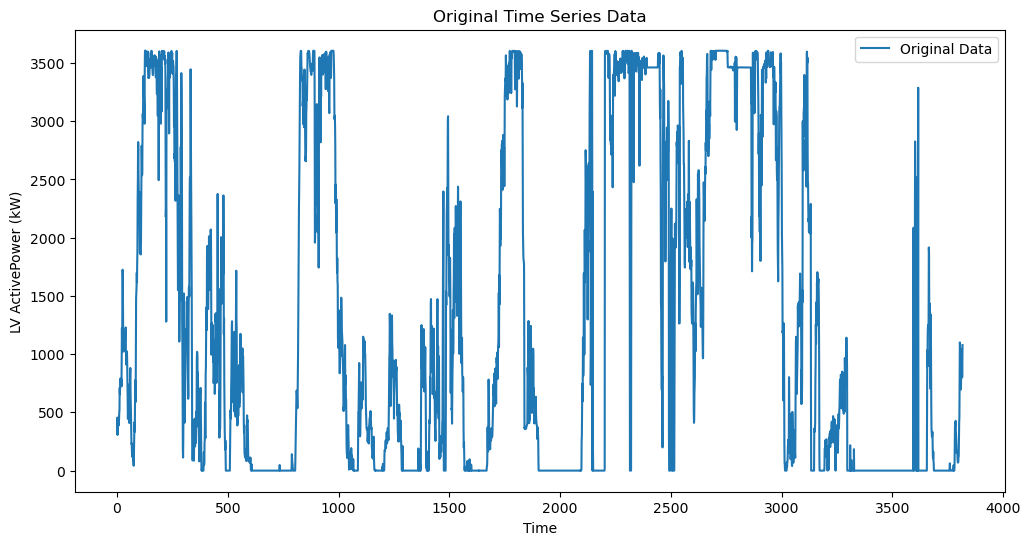

In [11]:
# Plot the original time series data
plt.figure(figsize=(12, 6))
plt.plot(data_wind.index, data_wind['LV ActivePower (kW)'].values, label='Original Data')
plt.title('Original Time Series Data')
plt.xlabel('Time')
plt.ylabel('LV ActivePower (kW)')
plt.legend()
plt.show()

In [12]:
# find the total number of rows
total_rows = data_wind.count()
total_rows

LV ActivePower (kW)              3817
Wind Direction (°)               3817
Theoretical_Power_Curve (KWh)    3817
Wind Speed (m/s)                 3817
dtype: int64

In [13]:
features.head()

,LV ActivePower (kW),Wind Direction (°),Theoretical_Power_Curve (KWh),Wind Speed (m/s)
0,380.047791,259.994904,416.328908,1.842347
1,453.769196,268.641113,519.917511,1.897945
2,306.376587,272.564789,390.900016,1.827133
3,419.645905,271.258087,516.127569,1.896071
4,380.650696,265.674286,491.702972,1.883722


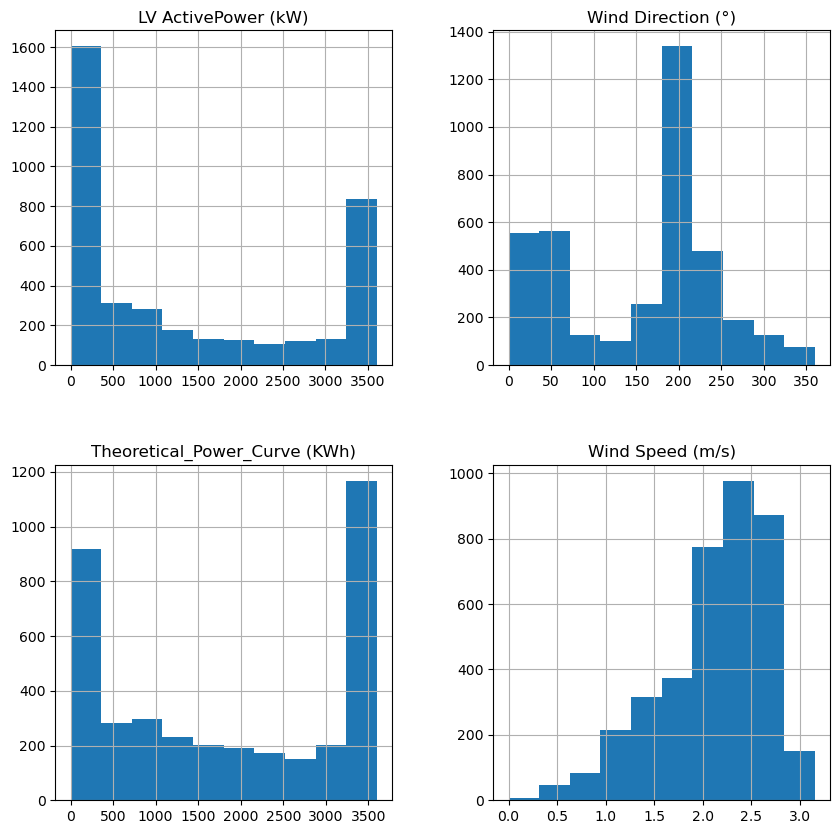

In [14]:
# plot the distribution of the features
features.hist(figsize=(10, 10))
plt.show()


In [15]:
features_scaled.head()

,Theoretical_Power_Curve (KWh),Wind Direction (°),LV ActivePower (kW),Wind Speed (m/s)
0,0.115647,0.722208,0.105673,0.583596
1,0.144422,0.746225,0.126120,0.601208
2,0.108583,0.757124,0.085240,0.578777
3,0.143369,0.753495,0.116656,0.600614
4,0.136584,0.737984,0.105840,0.596703


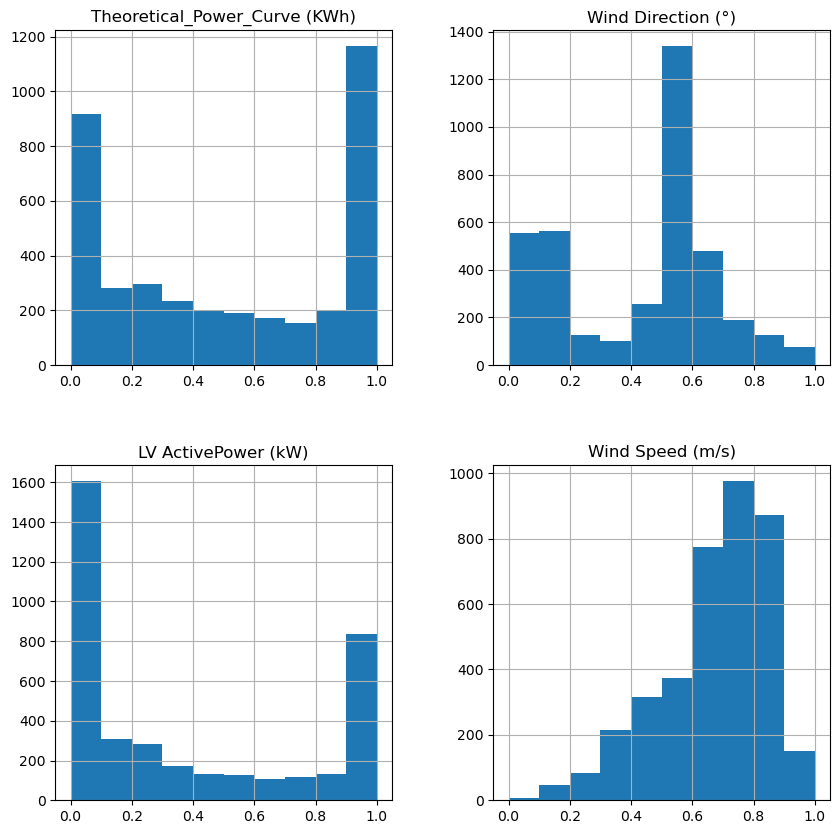

In [16]:
# plot the distribution of the features
features_scaled.hist(figsize=(10, 10))
plt.show()

In [17]:
target_scaler = MinMaxScaler()
target_scaled = pd.DataFrame(target_scaler.fit_transform(target.values.reshape(-1, 1)).flatten())

In [18]:
target_scaled

,0
0,0.105673
1,0.126120
2,0.085240
3,0.116656
4,0.105840
...,...
3812,0.289519
3813,0.288987
3814,0.221914
3815,0.224325


In [19]:
from PyEMD import EMD, EEMD, CEEMDAN
import ewtpy

# Decompose each input feature and target using CEEMDAN
def decompose_with_ceemdan(series, noise_seed=12345):
    emd = CEEMDAN(epsilon=0.05, max_imf=8)
    emd.noise_seed(noise_seed)
    return pd.DataFrame(emd.emd(series.values)).T

# Decompose features and target
decomposed_features = {col: decompose_with_ceemdan(features_scaled[col]) for col in features.columns}
decomposed_target = decompose_with_ceemdan(target_scaled[0])

# Apply EWT to the first IMF of each feature and target
def apply_ewt_to_first_imf(imf):
    ewt_coeffs, _, _ = ewtpy.EWT1D(imf.values, N=3)
    denoised_imf = pd.DataFrame(ewt_coeffs).sum(axis=1)
    return denoised_imf

for col in decomposed_features:
    decomposed_features[col].iloc[:, 0] = apply_ewt_to_first_imf(decomposed_features[col].iloc[:, 0])
decomposed_target.iloc[:, 0] = apply_ewt_to_first_imf(decomposed_target.iloc[:, 0])

# Ensure all components have the same number of IMFs
min_imfs = min(min(df.shape[1] for df in decomposed_features.values()), decomposed_target.shape[1])
for col in decomposed_features:
    decomposed_features[col] = decomposed_features[col].iloc[:, :min_imfs]
decomposed_target = decomposed_target.iloc[:, :min_imfs]


In [20]:
decomposed_features['LV ActivePower (kW)']

,0,1,2,3,4,5,6,7,8,9
0,0.002111,-0.002610,0.000313,-0.000764,-0.155801,0.054014,-0.415506,0.253379,0.101997,0.268943
1,0.014788,0.005975,-0.000212,-0.001341,-0.156032,0.056663,-0.419029,0.253599,0.101981,0.269028
2,-0.013879,-0.005974,0.000101,-0.000252,-0.155108,0.059013,-0.422422,0.253823,0.101964,0.269112
3,0.012847,-0.005388,-0.000245,0.000898,-0.152848,0.061066,-0.425682,0.254051,0.101947,0.269197
4,-0.011090,0.005963,0.000715,0.000570,-0.149207,0.062827,-0.428806,0.254284,0.101930,0.269282
...,...,...,...,...,...,...,...,...,...,...
3812,0.086925,-0.020875,-0.044164,0.074480,0.040717,0.010062,0.144360,0.120220,-0.454822,0.360902
3813,0.064051,-0.000393,-0.048790,0.078095,0.041069,0.012691,0.143728,0.120212,-0.454718,0.360821
3814,-0.027652,0.020483,-0.048444,0.079495,0.040955,0.015188,0.143084,0.120200,-0.454610,0.360740
3815,-0.043102,0.034068,-0.043446,0.078861,0.040347,0.017552,0.142427,0.120183,-0.454500,0.360659


In [21]:
decomposed_target

,0,1,2,3,4,5,6,7,8,9
0,0.002111,-0.002610,0.000313,-0.000764,-0.155801,0.054014,-0.415506,0.253379,0.101997,0.268943
1,0.014788,0.005975,-0.000212,-0.001341,-0.156032,0.056663,-0.419029,0.253599,0.101981,0.269028
2,-0.013879,-0.005974,0.000101,-0.000252,-0.155108,0.059013,-0.422422,0.253823,0.101964,0.269112
3,0.012847,-0.005388,-0.000245,0.000898,-0.152848,0.061066,-0.425682,0.254051,0.101947,0.269197
4,-0.011090,0.005963,0.000715,0.000570,-0.149207,0.062827,-0.428806,0.254284,0.101930,0.269282
...,...,...,...,...,...,...,...,...,...,...
3812,0.086925,-0.020875,-0.044164,0.074480,0.040717,0.010062,0.144360,0.120220,-0.454822,0.360902
3813,0.064051,-0.000393,-0.048790,0.078095,0.041069,0.012691,0.143728,0.120212,-0.454718,0.360821
3814,-0.027652,0.020483,-0.048444,0.079495,0.040955,0.015188,0.143084,0.120200,-0.454610,0.360740
3815,-0.043102,0.034068,-0.043446,0.078861,0.040347,0.017552,0.142427,0.120183,-0.454500,0.360659


In [22]:
for col in decomposed_features:
    num_feature_imfs = decomposed_features[col].shape[1]
    for i in range(min_imfs):
        correlation = decomposed_features[col].iloc[:, i].corr(decomposed_target.iloc[:, i])
        print(f"Correlation between {col} IMF {i+1} and Target IMF {i+1}: {correlation}")

Correlation between LV ActivePower (kW) IMF 1 and Target IMF 1: 0.9999999999999999
Correlation between LV ActivePower (kW) IMF 2 and Target IMF 2: 1.0
Correlation between LV ActivePower (kW) IMF 3 and Target IMF 3: 1.0
Correlation between LV ActivePower (kW) IMF 4 and Target IMF 4: 1.0
Correlation between LV ActivePower (kW) IMF 5 and Target IMF 5: 1.0
Correlation between LV ActivePower (kW) IMF 6 and Target IMF 6: 1.0
Correlation between LV ActivePower (kW) IMF 7 and Target IMF 7: 1.0
Correlation between LV ActivePower (kW) IMF 8 and Target IMF 8: 1.0
Correlation between LV ActivePower (kW) IMF 9 and Target IMF 9: 1.0
Correlation between LV ActivePower (kW) IMF 10 and Target IMF 10: 1.0
Correlation between Wind Direction (°) IMF 1 and Target IMF 1: -0.0029090311852137717
Correlation between Wind Direction (°) IMF 2 and Target IMF 2: 0.004454107203678574
Correlation between Wind Direction (°) IMF 3 and Target IMF 3: -0.004459841121825882
Correlation between Wind Direction (°) IMF 4 and

In [23]:
# Prepare for individual IMF training
num_imfs = decomposed_target.shape[1]  # Number of IMFs in the target

In [24]:
for i in range(decomposed_target.shape[1]):
    print(f"IMF {i+1}: Mean={decomposed_target.iloc[:, i].mean()}, Std={decomposed_target.iloc[:, i].std()}")

for col in decomposed_features:
    for i in range(decomposed_features[col].shape[1]):
        print(f"{col} IMF {i+1}: Mean={decomposed_features[col].iloc[:, i].mean()}, Std={decomposed_features[col].iloc[:, i].std()}")

IMF 1: Mean=0.0013719417463071547, Std=0.12123429515150479
IMF 2: Mean=-0.0005990380764153309, Std=0.06890543670744365
IMF 3: Mean=0.0026983213696883117, Std=0.1156551361502708
IMF 4: Mean=-0.0012787531776220654, Std=0.13264658038975216
IMF 5: Mean=-0.009091458175863902, Std=0.1514572601231501
IMF 6: Mean=-0.007795725186188872, Std=0.18684577174787262
IMF 7: Mean=-0.005389088714727296, Std=0.17456249024725817
IMF 8: Mean=-0.00014022154262157137, Std=0.15835385309642222
IMF 9: Mean=-0.004416020892673979, Std=0.21894452815882282
IMF 10: Mean=0.39189069694383194, Std=0.05093908650995535
LV ActivePower (kW) IMF 1: Mean=0.0013719417463071547, Std=0.12123429515150479
LV ActivePower (kW) IMF 2: Mean=-0.0005990380764153309, Std=0.06890543670744365
LV ActivePower (kW) IMF 3: Mean=0.0026983213696883117, Std=0.1156551361502708
LV ActivePower (kW) IMF 4: Mean=-0.0012787531776220654, Std=0.13264658038975216
LV ActivePower (kW) IMF 5: Mean=-0.009091458175863902, Std=0.1514572601231501
LV ActivePower

In [25]:
decomposed_target.head()

,0,1,2,3,4,5,6,7,8,9
0,0.002111,-0.002610,0.000313,-0.000764,-0.155801,0.054014,-0.415506,0.253379,0.101997,0.268943
1,0.014788,0.005975,-0.000212,-0.001341,-0.156032,0.056663,-0.419029,0.253599,0.101981,0.269028
2,-0.013879,-0.005974,0.000101,-0.000252,-0.155108,0.059013,-0.422422,0.253823,0.101964,0.269112
3,0.012847,-0.005388,-0.000245,0.000898,-0.152848,0.061066,-0.425682,0.254051,0.101947,0.269197
4,-0.011090,0.005963,0.000715,0.000570,-0.149207,0.062827,-0.428806,0.254284,0.101930,0.269282


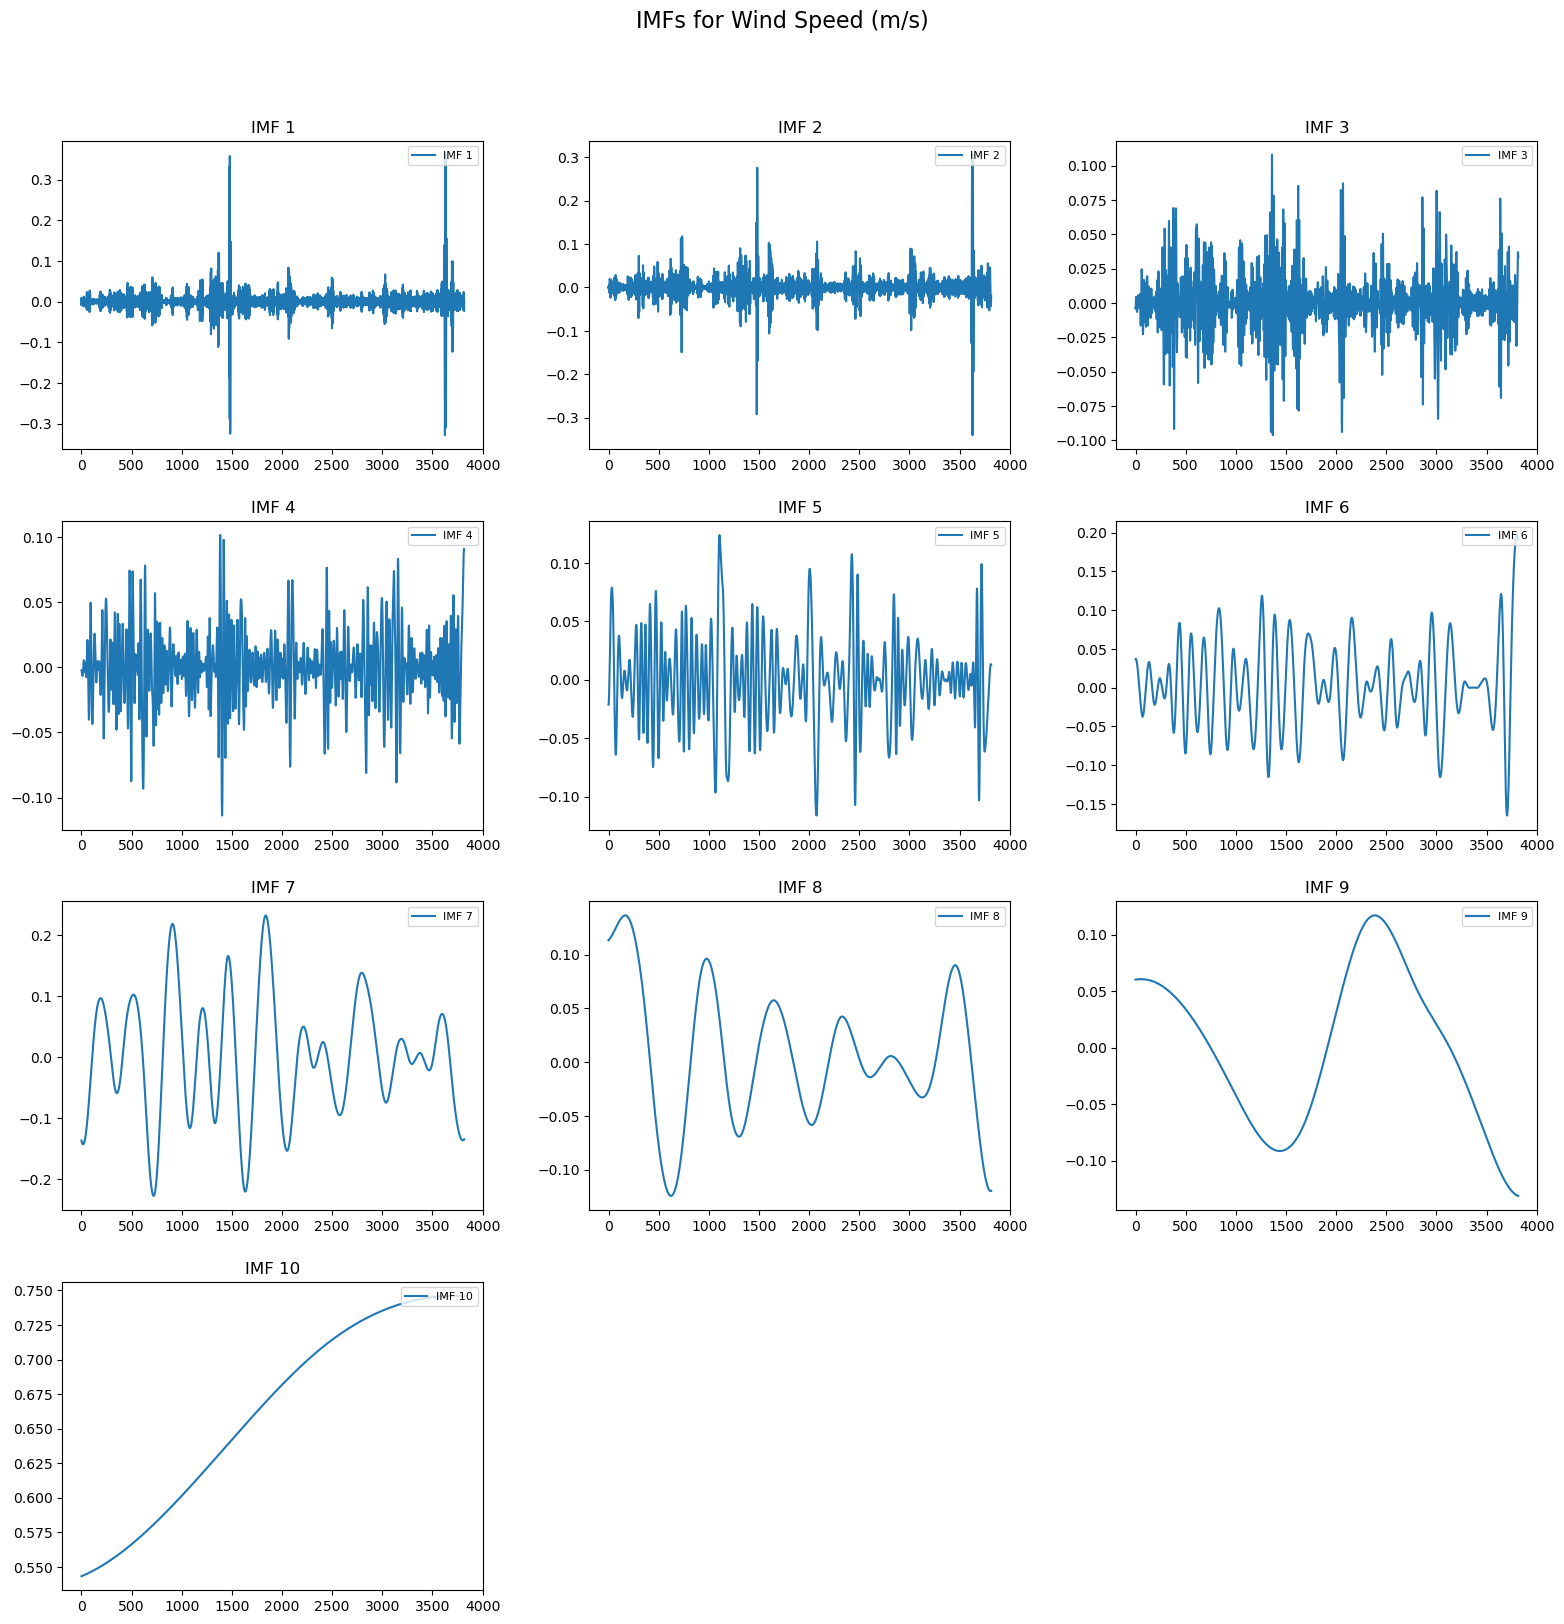

In [26]:
import matplotlib.pyplot as plt
import math
    
# Function to determine optimal grid dimensions
def get_grid_dimensions(n):
    rows = math.ceil(math.sqrt(n))
    cols = math.ceil(n / rows)
    return rows, cols

rows, cols = get_grid_dimensions(num_imfs)

plt.figure(figsize=(16, 4 * rows))  # Adjust figure size based on the number of rows
plt.suptitle(f"IMFs for {col}", fontsize=16, y=1.02)  # Add title for the column
    
for idx in range(num_imfs):
    plt.subplot(rows, cols, idx + 1)
    plt.plot(decomposed_features[col].iloc[:, idx], label=f'IMF {idx + 1}')
    plt.title(f'IMF {idx + 1}')
    plt.legend(loc='upper right', fontsize=8)
    plt.tight_layout(pad=2.0)
    
plt.show()

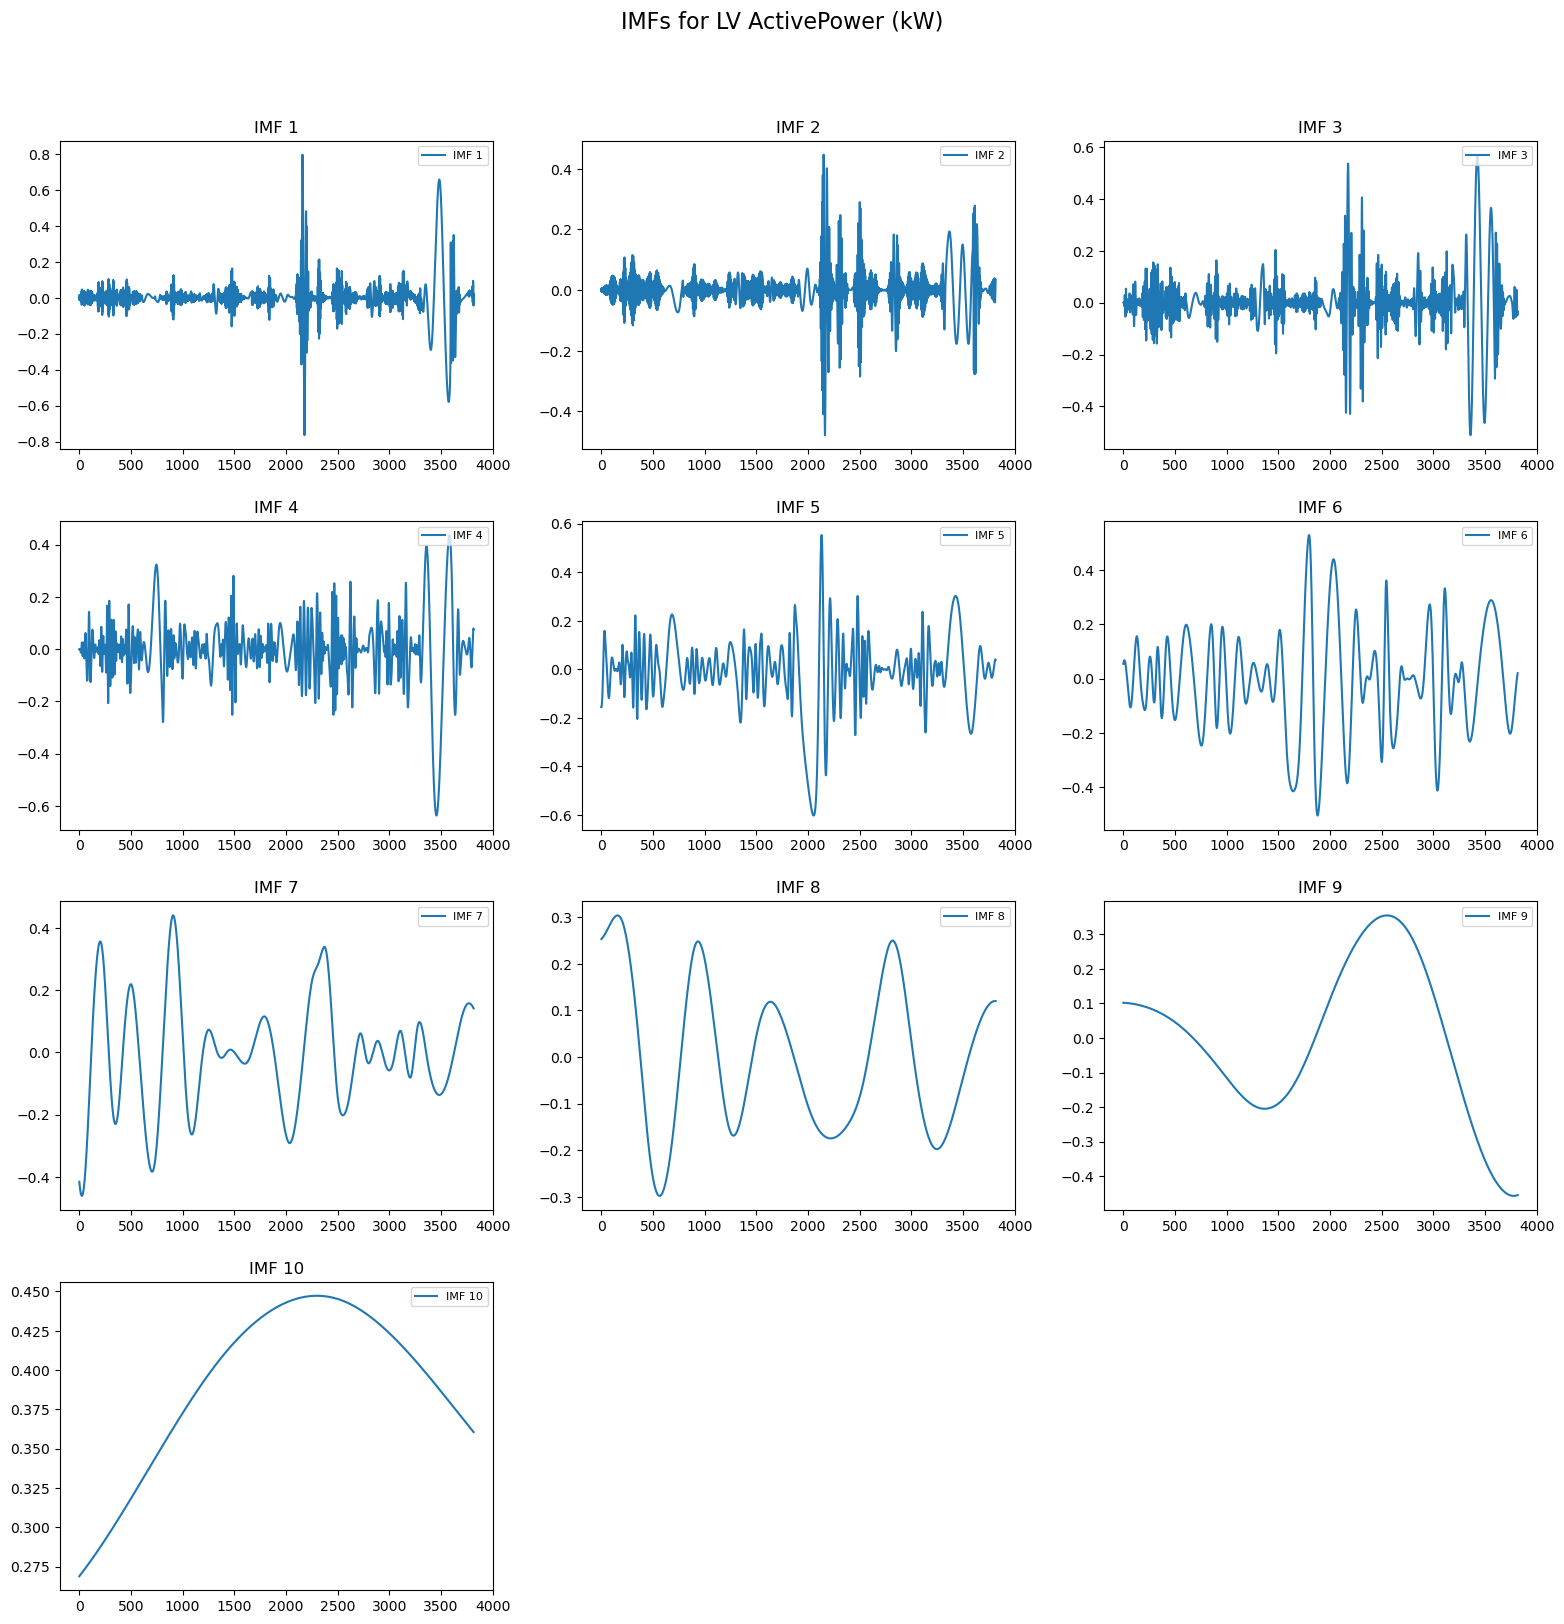

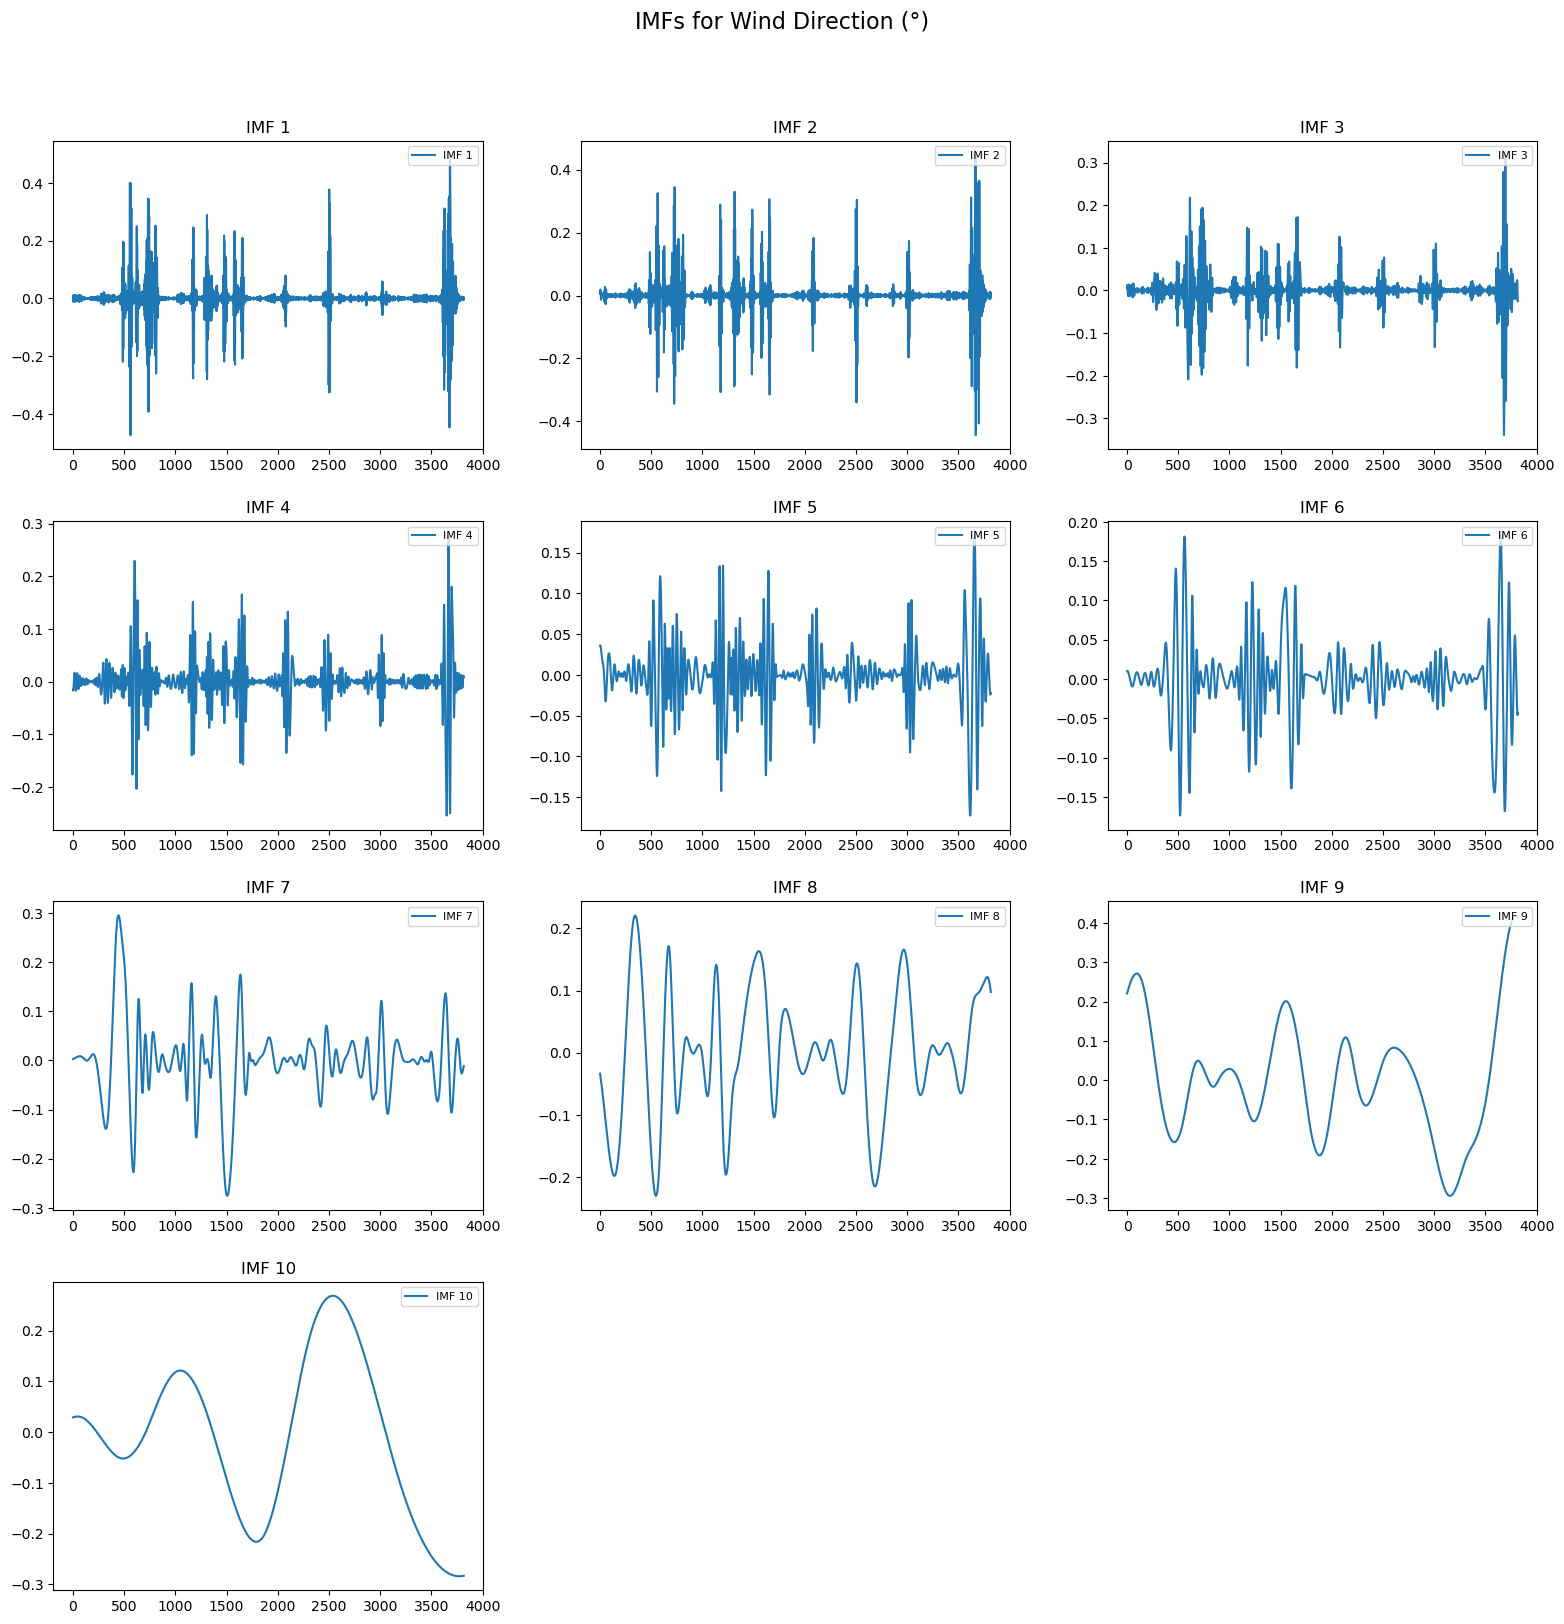

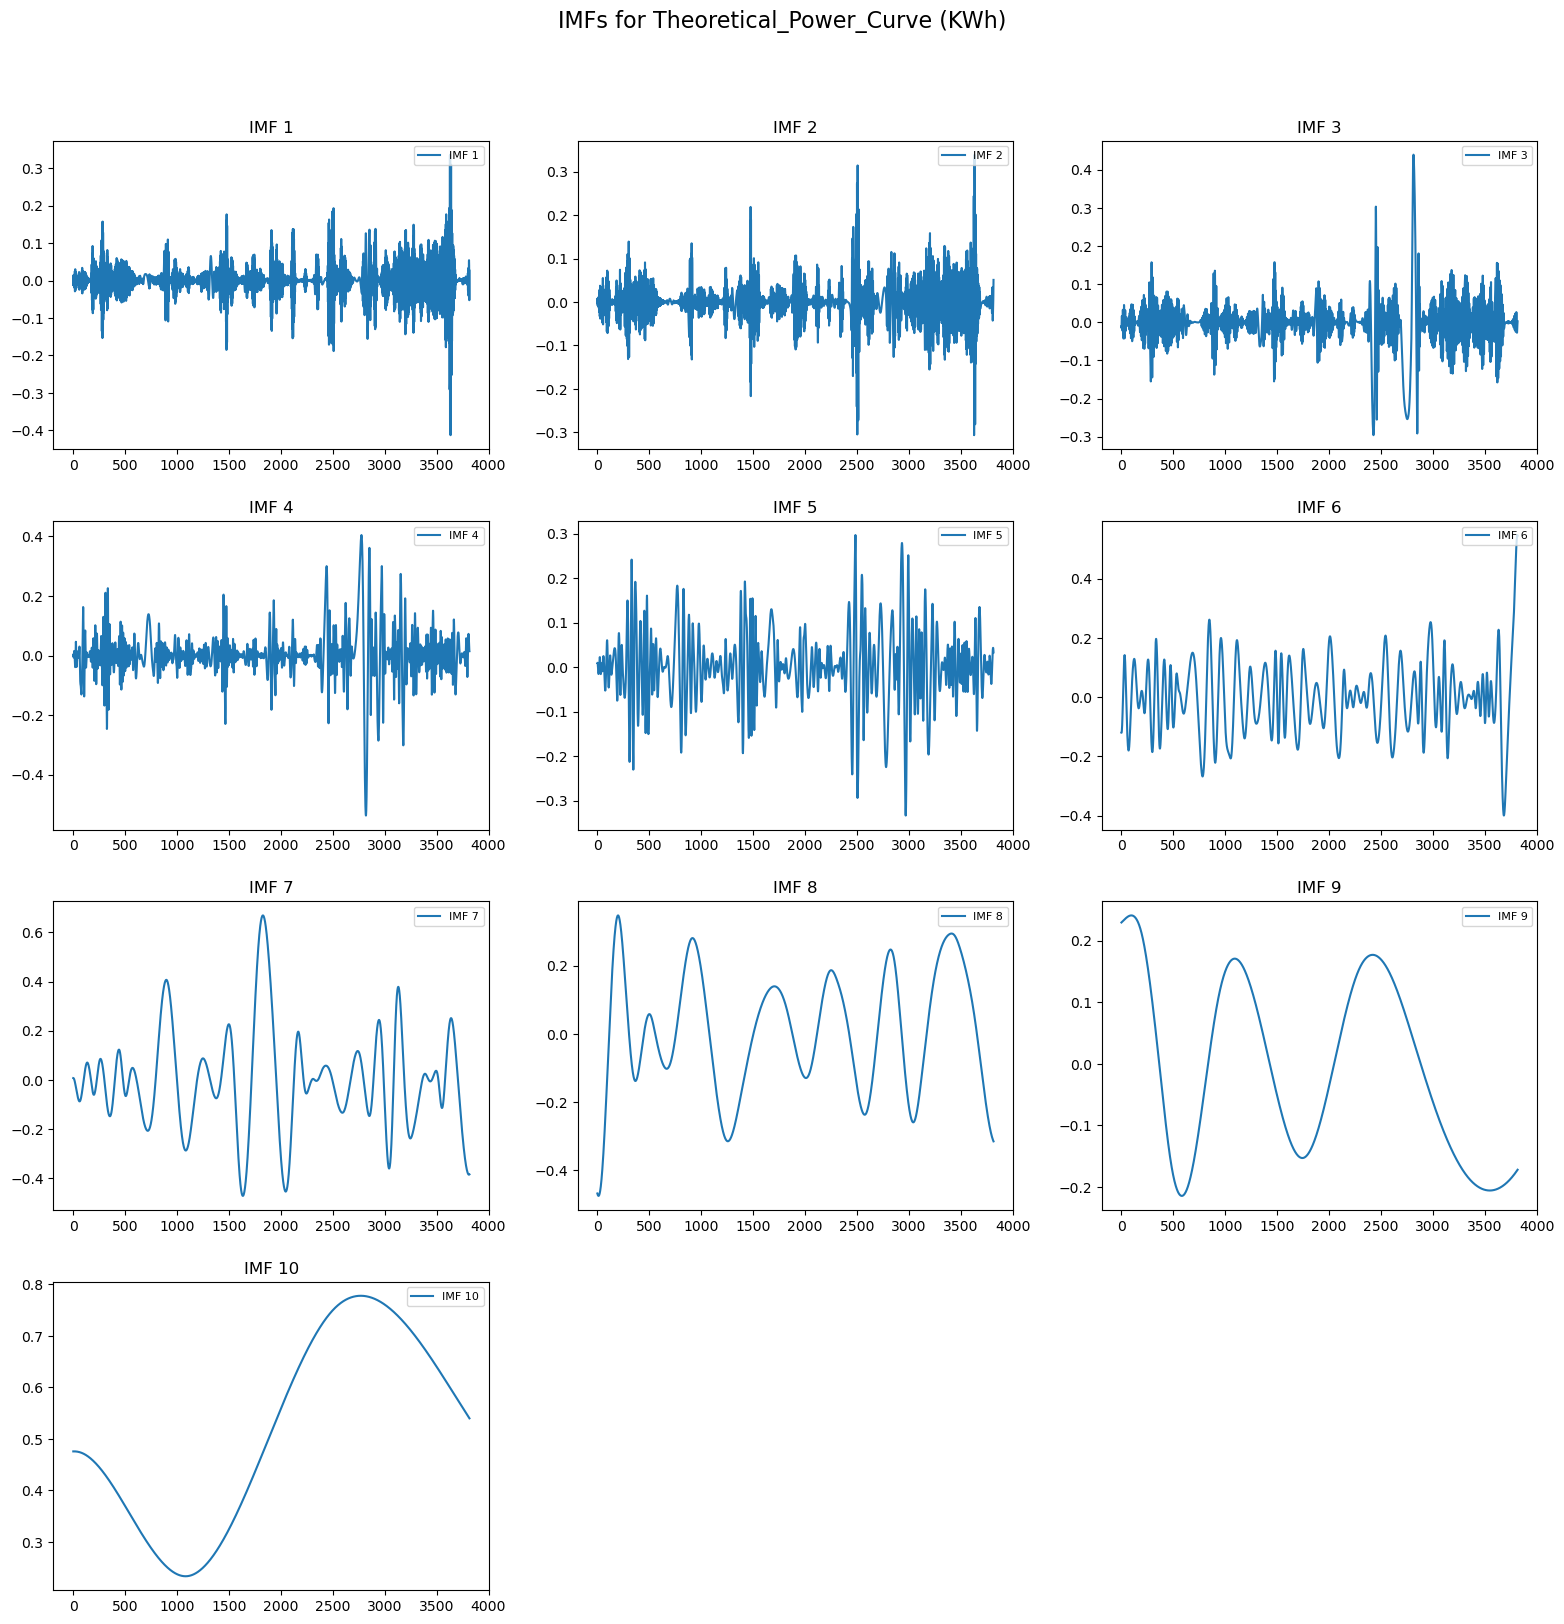

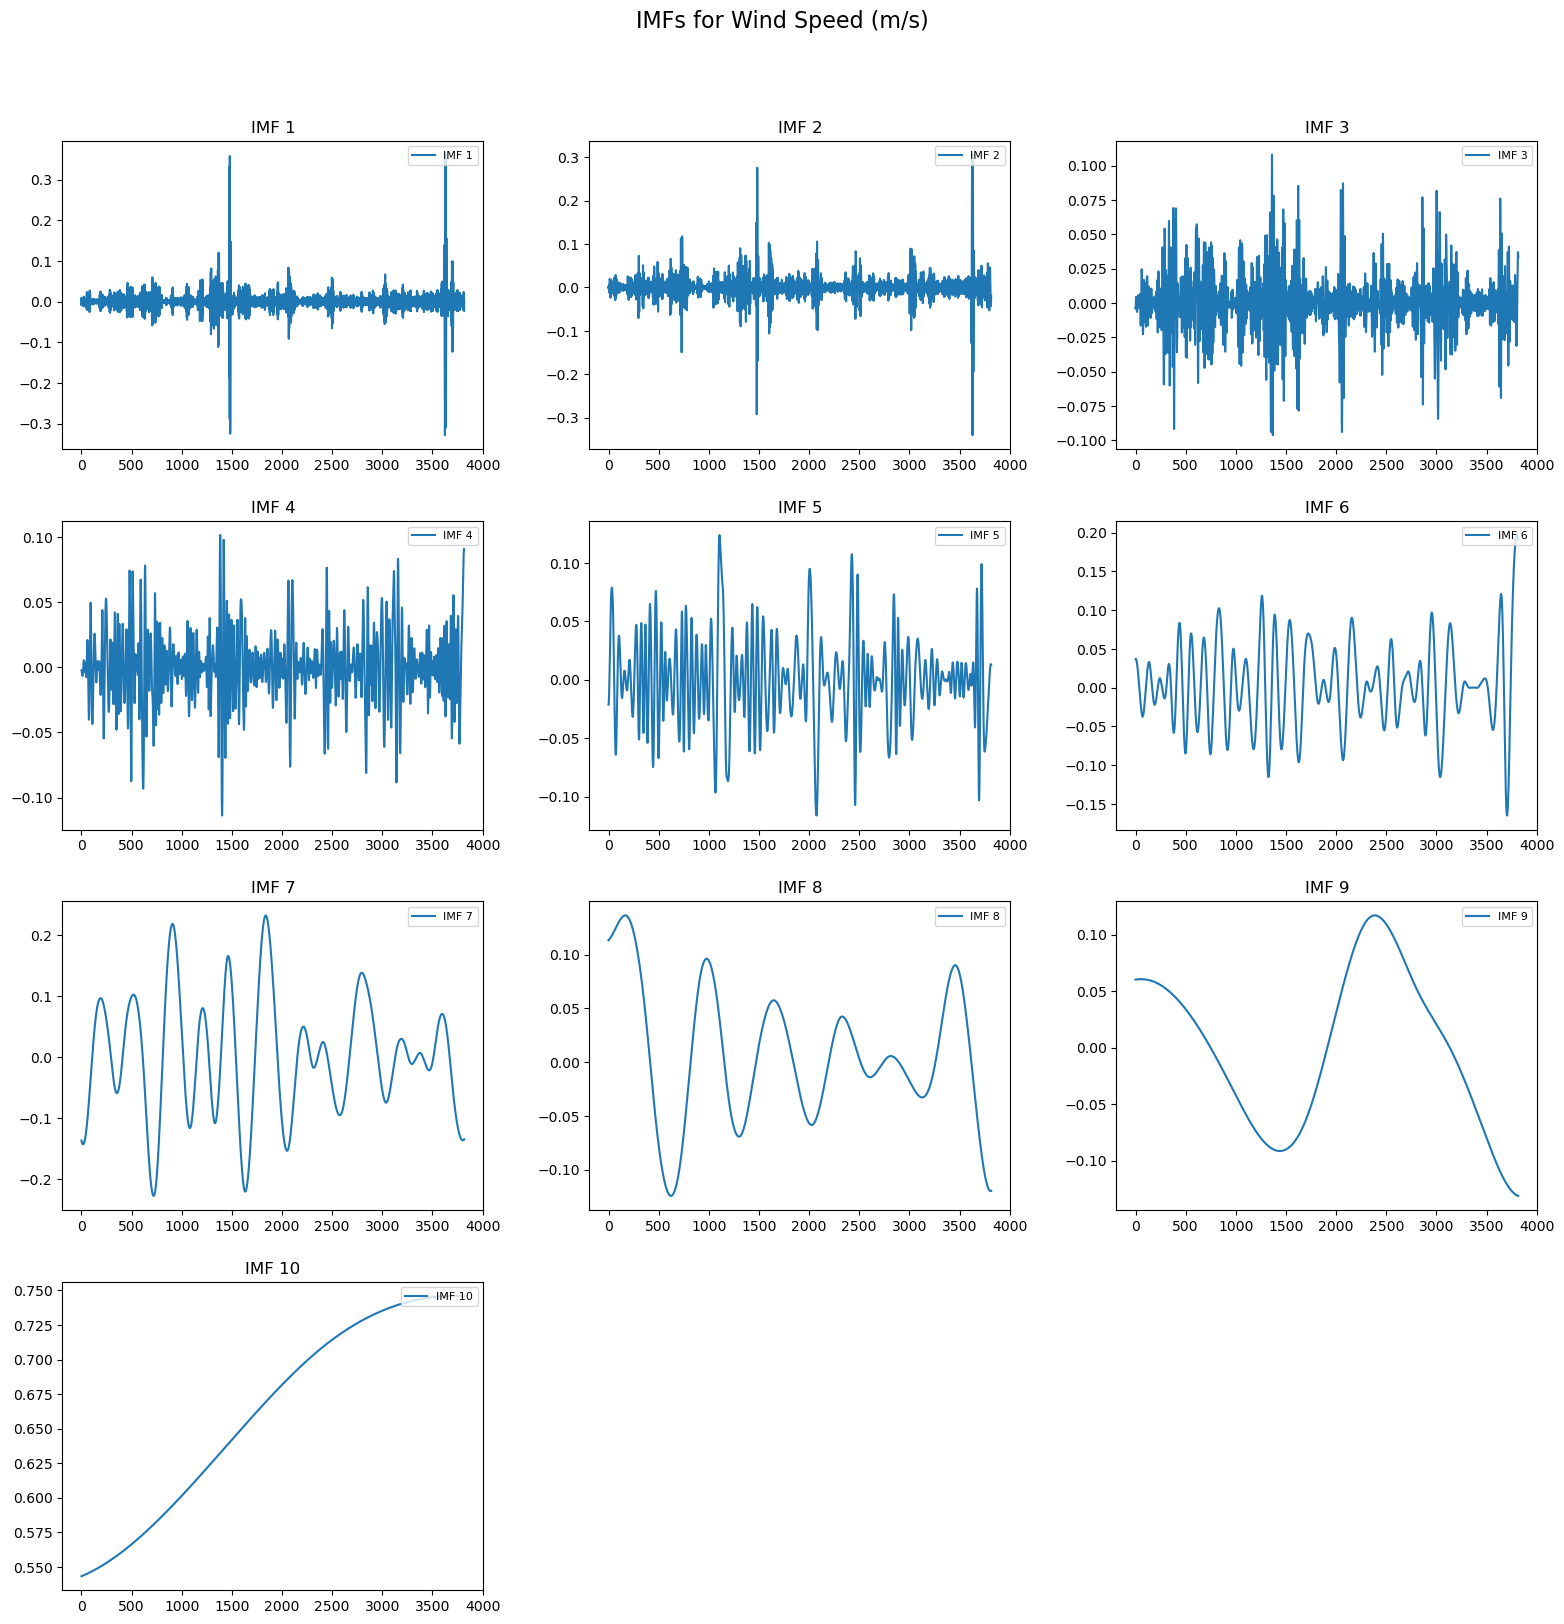

In [27]:
# Function to determine optimal grid dimensions
def get_grid_dimensions(n):
    rows = math.ceil(math.sqrt(n))
    cols = math.ceil(n / rows)
    return rows, cols

for col in decomposed_features:
    num_imfs = decomposed_features[col].shape[1]
    rows, cols = get_grid_dimensions(num_imfs)
    
    plt.figure(figsize=(16, 4 * rows))  # Adjust figure size based on the number of rows
    plt.suptitle(f"IMFs for {col}", fontsize=16, y=1.02)  # Add title for the column
    
    for idx in range(num_imfs):
        plt.subplot(rows, cols, idx + 1)
        plt.plot(decomposed_features[col].iloc[:, idx], label=f'IMF {idx + 1}')
        plt.title(f'IMF {idx + 1}')
        plt.legend(loc='upper right', fontsize=8)
        plt.tight_layout(pad=2.0)
    
    plt.show()


In [28]:
# Variable Selection with Elastic Net
selected_imfs = []  # To store selected IMFs
alpha_values = np.logspace(-3, 1, 50)  # Define alpha values for ElasticNetCV
for i in range(min_imfs):
    print(f"Performing ElasticNet for IMF {i+1}...")
    X_imf = pd.concat([decomposed_features[col].iloc[:, i] for col in decomposed_features], axis=1)
    y_imf = decomposed_target.iloc[:, i]

    # Apply ElasticNetCV
    elastic_net = ElasticNetCV(alphas=alpha_values, l1_ratio=0.5, cv=5, random_state=42)
    elastic_net.fit(X_imf, y_imf)

    # Check if ElasticNet selected this IMF
    if np.any(elastic_net.coef_ != 0):
        selected_imfs.append(i)

print(f"Selected IMFs: {selected_imfs}")


Performing ElasticNet for IMF 1...
Performing ElasticNet for IMF 2...
Performing ElasticNet for IMF 3...
Performing ElasticNet for IMF 4...
Performing ElasticNet for IMF 5...
Performing ElasticNet for IMF 6...
Performing ElasticNet for IMF 7...
Performing ElasticNet for IMF 8...
Performing ElasticNet for IMF 9...
Performing ElasticNet for IMF 10...
Selected IMFs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [29]:
# Create sequences
def create_sequences(features, target, input_length, output_length):
    x, y = [], []
    for j in range(len(features) - input_length - output_length + 1):
        x.append(features.iloc[j:j + input_length].values)
        y.append(target.iloc[j + input_length:j + input_length + output_length].values)
    return np.array(x), np.array(y)

In [30]:
# Prepare lists to store predictions and actual values
pred_train = []
pred_test = []
train_ori = []
test_ori = []

# Model parameters
epoch = 30
batch_size = 64
neuron = 32
lr = 0.001
input_length = 6
output_length = 1
data_partition = 0.8

In [31]:
# Evaluate each IMF
for i in selected_imfs:
    print(f"Processing IMF {i+1}...")

    # Combine IMFs of all features for the current IMF index
    combined_imf = pd.concat([decomposed_features[col].iloc[:, i] for col in decomposed_features], axis=1)
    target_imf = decomposed_target.iloc[:, i]

    # Prepare training and testing data for the current IMF
    train_size = int(len(combined_imf) * data_partition)
    train_features, test_features = combined_imf[:train_size], combined_imf[train_size:]
    train_target, test_target = target_imf[:train_size], target_imf[train_size:]

    # Create sequences
    X_train, y_train = create_sequences(train_features, train_target, input_length, output_length)
    X_test, y_test = create_sequences(test_features, test_target, input_length, output_length)

    if len(X_train) == 0 or len(X_test) == 0:
        continue  # Skip if there is not enough data for this component

    # Reshape data for 
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], -1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)

    # Build and compile a deeper GRU model
    model = Sequential()
    model.add(GRU(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(0.1))
    model.add(GRU(units=32, return_sequences=False))
    model.add(Dense(1))
    optimizer = keras.optimizers.AdamW(learning_rate=lr)
    model.compile(loss='mae', optimizer=optimizer)


    # Train the model
    model.fit(X_train, y_train, epochs=epoch, batch_size=batch_size, verbose=0)

    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Inverse transform predictions and actual values for the current IMF
    y_pred_train_inv = target_scaler.inverse_transform(y_pred_train)
    y_pred_test_inv = target_scaler.inverse_transform(y_pred_test)
    y_train_inv = target_scaler.inverse_transform(y_train.reshape(-1, 1))
    y_test_inv = target_scaler.inverse_transform(y_test.reshape(-1, 1))

    
    # Debug: Check if scaling is consistent
    print(f"IMF {i+1}: Predicted (scaled): {y_pred_test[:5].flatten()}")
    print(f"IMF {i+1}: Actual (scaled): {y_test[:5].flatten()}")
    print(f"IMF {i+1}: Predicted (inverse): {y_pred_test_inv[:5].flatten()}")
    print(f"IMF {i+1}: Actual (inverse): {y_test_inv[:5].flatten()}")


    # Store predictions and actual values
    pred_train.append(y_pred_train_inv.flatten())
    pred_test.append(y_pred_test_inv.flatten())
    train_ori.append(y_train_inv.flatten())
    test_ori.append(y_test_inv.flatten())


Processing IMF 1...


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
IMF 1: Predicted (scaled): [-0.0046442  -0.01701446 -0.00301911 -0.02015495  0.00155437]
IMF 1: Actual (scaled): [-0.01531392  0.00307107 -0.01967941  0.00968196 -0.02784686]
IMF 1: Predicted (inverse): [-17.703768 -62.304974 -11.844476 -73.62807    4.645314]
IMF 1: Actual (inverse): [ -56.17364379   10.1137938   -71.91351871   33.94948878 -101.36140627]
Processing IMF 2...


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
IMF 2: Predicted (scaled): [ 0.04141922 -0.03613432 -0.04701202 -0.03514712 -0.01810811]
IMF 2: Actual (scaled): [ 0.01891377 -0.03207677 -0.05191623 -0.04220599  0.00405207]
IMF 2: Predicted (inverse): [ 148.37883 -131.242   -170.46178 -127.68265  -66.24816]
IMF 2: Actual (inverse): [  67.23496856 -116.61241883 -188.14400496 -153.13354561   13.65082193]
Processing IMF 3...


...

96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
IMF 8: Predicted (scaled): [-0.05289706 -0.0543064  -0.05571075 -0.05711003 -0.05850424]
IMF 8: Actual (scaled): [-0.0589076  -0.06033743 -0.06176138 -0.06317941 -0.06459148]
IMF 8: Predicted (inverse): [-191.68042 -196.76183 -201.82524 -206.87038 -211.89722]
IMF 8: Actual (inverse): [-213.35151758 -218.50679752 -223.64088179 -228.75361982 -233.84486105]
Processing IMF 9...


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
IMF 9: Predicted (scaled): [0.0767695  0.07578284 0.07479545 0.07380731 0.07281844]
IMF 9: Actual (scaled): [0.07017236 0.06916277 0.06815241 0.06714127 0.06612937]
IMF 9: Predicted (inverse): [275.835   272.27753 268.7175  265.15472 261.58936]
IMF 9: Actual (inverse): [252.04884951 248.40876484 244.76587623 241.12020826 237.47178551]
Processing IMF 10...


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
IMF 10: Predicted (scaled): [0.4194867  0.41941544 0.41934407 0.41927272 0.41920125]
IMF 10: Actual (scaled): [0.41971281 0.41964667 0.41958048 0.41951424 0.41944794]
IMF 10: Predicted (inverse): [1511.5087 1511.2517 1510.9944 1510.7372 1510.4795]
IMF 10: Actual (inverse): [1512.32393447 1512.08548913 1511.84684379 1511.6079988  1511.36895449]


In [32]:
# Convert lists to DataFrames
result_pred_test = pd.DataFrame(pred_test).T  # Transpose to align with actual values
result_pred_train = pd.DataFrame(pred_train).T


# Sum predictions across components
a = result_pred_test.sum(axis=1)
b = result_pred_train.sum(axis=1)


In [33]:
# Prepare actual data
dataset = target.values.reshape(-1, 1)
train_size = int(len(dataset) * data_partition)
train, test = dataset[:train_size], dataset[train_size:]

# Create datasets for training and testing
_, trainY = create_sequences(pd.DataFrame(train), pd.DataFrame(train), input_length, output_length)
_, testY = create_sequences(pd.DataFrame(test), pd.DataFrame(test), input_length, output_length)

# Scale the data
sc_y_total = MinMaxScaler()
y_train_scaled = sc_y_total.fit_transform(trainY.reshape(-1, 1))
y_test_scaled = sc_y_total.transform(testY.reshape(-1, 1))

# Inverse transform actual values
y_test_inv = sc_y_total.inverse_transform(y_test_scaled).flatten()
y_train_inv = sc_y_total.inverse_transform(y_train_scaled).flatten()

In [34]:
# Ensure the lengths match
min_length = min(len(a), len(y_test_inv))
a = a[:min_length]
y_test_series = y_test_inv[:min_length]

# Calculate error metrics
rmse = np.sqrt(mean_squared_error(y_test_series, a))
mae = mean_absolute_error(y_test_series, a)
r2 = r2_score(y_test_series, a)

# Print the results
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}")

RMSE: 258.773
MAE: 157.462
R2: 0.868


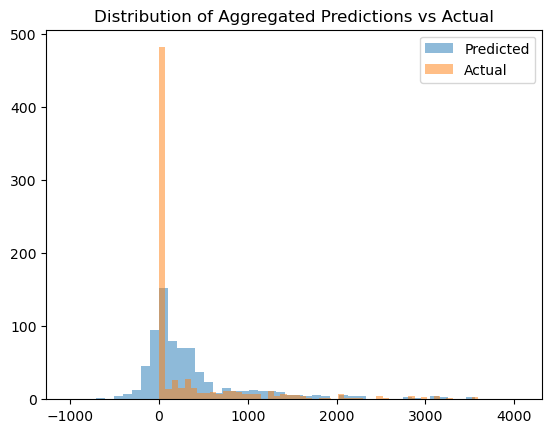

In [35]:
plt.hist(a, bins=50, alpha=0.5, label="Predicted")
plt.hist(y_test_series, bins=50, alpha=0.5, label="Actual")
plt.legend()
plt.title("Distribution of Aggregated Predictions vs Actual")
plt.show()


In [36]:
aggregated_signal = result_pred_test.sum(axis=1)  # Aggregated predictions
print(f"Aggregated Signal Mean: {aggregated_signal.mean()}, Std: {aggregated_signal.std()}")
print(f"Actual Signal Mean: {y_test_series.mean()}, Std: {y_test_series.std()}")


Aggregated Signal Mean: 406.73822021484375, Std: 710.0916137695312
Actual Signal Mean: 364.55901030169895, Std: 711.713816751563


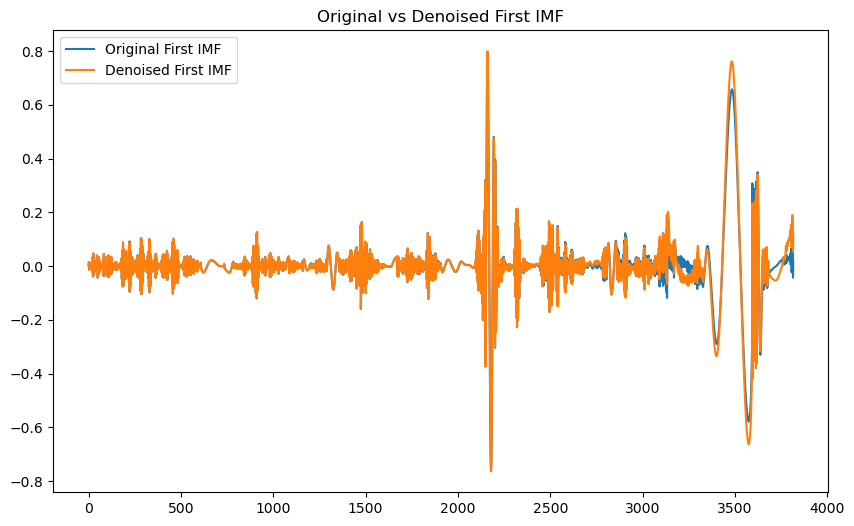

In [37]:
original_first_imf = decomposed_target.iloc[:, 0]  # Before denoising
denoised_first_imf = apply_ewt_to_first_imf(original_first_imf)  # After denoising

plt.figure(figsize=(10, 6))
plt.plot(original_first_imf, label="Original First IMF")
plt.plot(denoised_first_imf, label="Denoised First IMF")
plt.legend()
plt.title("Original vs Denoised First IMF")
plt.show()


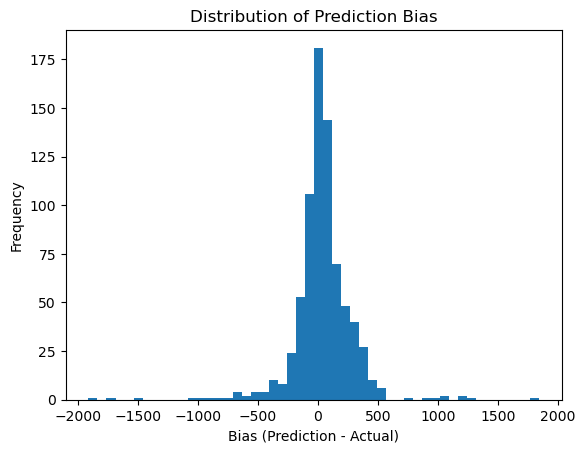

In [38]:
bias = aggregated_signal - y_test_series
plt.hist(bias, bins=50)
plt.title("Distribution of Prediction Bias")
plt.xlabel("Bias (Prediction - Actual)")
plt.ylabel("Frequency")
plt.show()


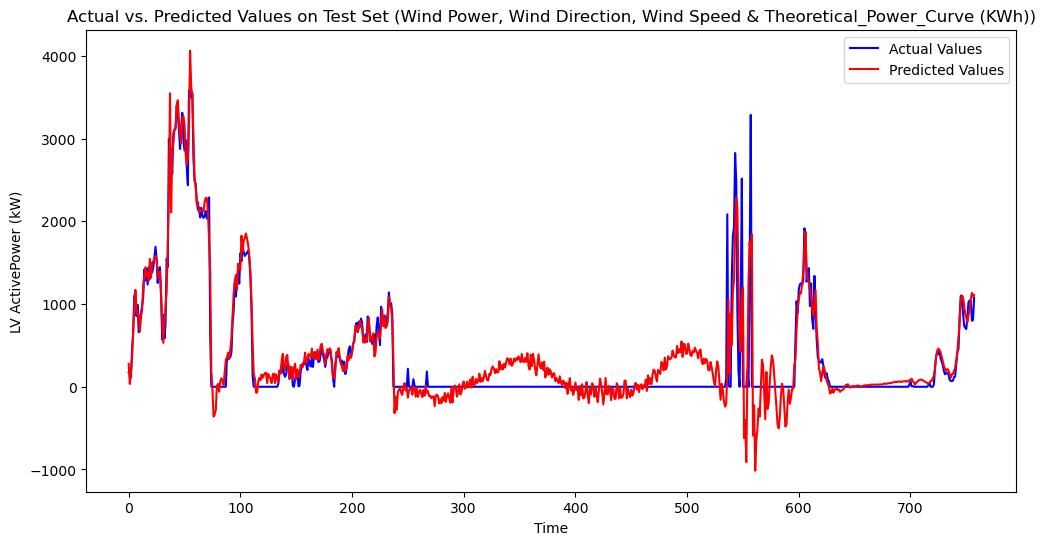

In [39]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_series, label='Actual Values', color='blue')
plt.plot(a.values, label='Predicted Values', color='red')
plt.title('Actual vs. Predicted Values on Test Set (Wind Power, Wind Direction, Wind Speed & Theoretical_Power_Curve (KWh))')
plt.xlabel('Time')
plt.ylabel('LV ActivePower (kW)')
plt.legend()
plt.show()


In [40]:
aggregated_signal[aggregated_signal < 0] = 0  # Set negative values to 0

In [41]:
# Ensure the lengths match
min_length = min(len(aggregated_signal), len(y_test_inv))
aggregated_signal = aggregated_signal[:min_length]
y_test_series = y_test_inv[:min_length]

# Calculate error metrics
rmse = np.sqrt(mean_squared_error(y_test_series, aggregated_signal))
mae = mean_absolute_error(y_test_series, aggregated_signal)
r2 = r2_score(y_test_series, aggregated_signal)

# Print the results
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}")

RMSE: 239.793
MAE: 127.803
R2: 0.886


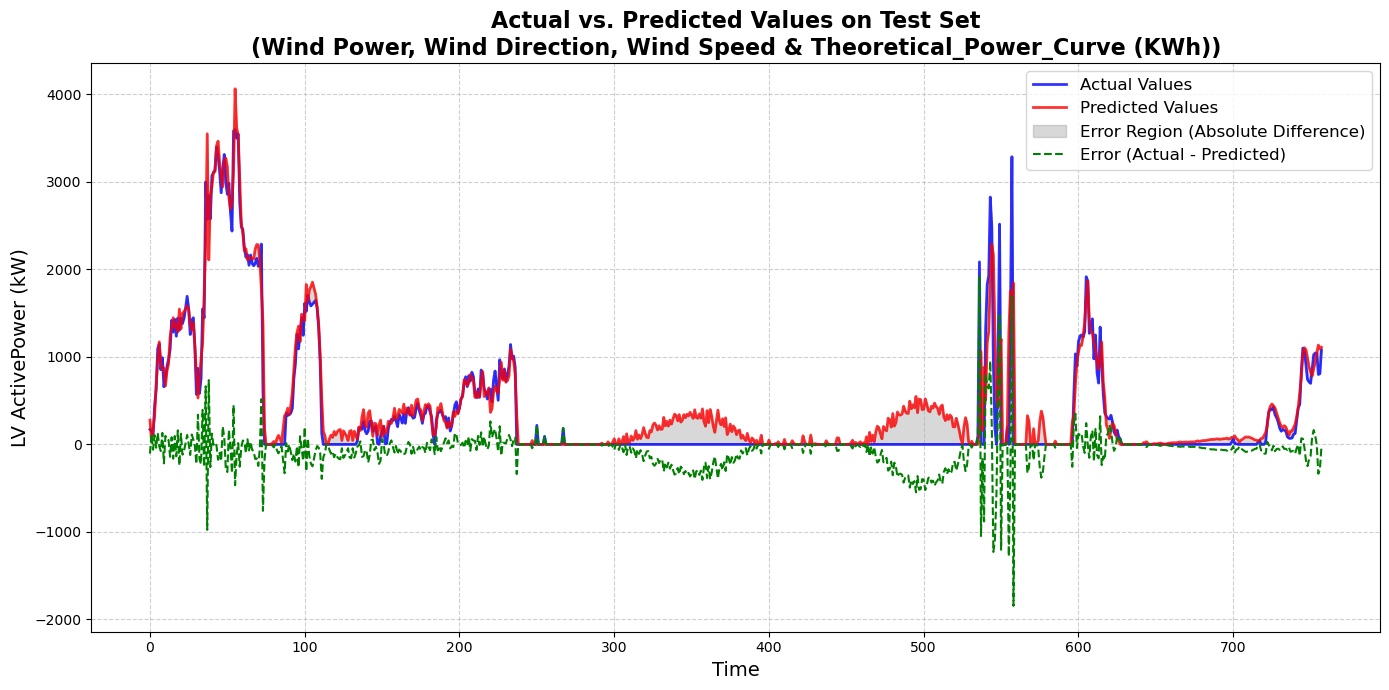

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the error
error = y_test_series - aggregated_signal

plt.figure(figsize=(14, 7))

# Plot actual values
plt.plot(
    y_test_series, 
    label='Actual Values', 
    color='blue', 
    linewidth=2, 
    alpha=0.8
)

# Plot predicted values
plt.plot(
    aggregated_signal, 
    label='Predicted Values', 
    color='red', 
    linewidth=2, 
    alpha=0.8
)

# Highlight the error region
plt.fill_between(
    range(len(y_test_series)), 
    y_test_series, 
    aggregated_signal, 
    color='gray', 
    alpha=0.3, 
    label='Error Region (Absolute Difference)'
)

# Plot error line
plt.plot(
    error, 
    label='Error (Actual - Predicted)', 
    color='green', 
    linestyle='--', 
    linewidth=1.5
)

# Add grid, labels, and legend
plt.title(
    'Actual vs. Predicted Values on Test Set\n(Wind Power, Wind Direction, Wind Speed & Theoretical_Power_Curve (KWh))', 
    fontsize=16, 
    fontweight='bold'
)
plt.xlabel('Time', fontsize=14)
plt.ylabel('LV ActivePower (kW)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(visible=True, linestyle='--', alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()
